# camel beauty assessor — dataset eda

three roboflow exports in two annotation batches, one canonical 9-class schema.
this notebook checks them, merges them, and verifies nothing was lost.

## 1. setup

### 1.1 imports

In [1]:
import os
import re
import csv
import shutil
import collections

import yaml
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import imagehash

### 1.2 paths

`root` is where the untouched roboflow exports live. the merge writes outside it,
so nothing generated here can ever land back among the originals.

In [2]:
root = "dataset/original"
out = "dataset/camel-merged-v1"

### 1.3 display options

In [3]:
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.expand_frame_repr", False)

### 1.4 the class schema

the mixed hyphen/underscore punctuation is deliberate. roboflow numbers classes by
ascii-sorting their names, so "tidying" it renumbers every class in every export.

In [4]:
canon = ["Camel", "High_withers", "Large-head", "Large-lips", "Large-nose",
         "Large_hump", "Long-legs", "Long-neck", "Wide_body"]

traits = [c for c in canon if c != "Camel"]

pd.DataFrame({"class_id": range(len(canon)), "name": canon}).set_index("class_id")

,name
class_id,
0,Camel
1,High_withers
2,Large-head
3,Large-lips
4,Large-nose
5,Large_hump
6,Long-legs
7,Long-neck
8,Wide_body


### 1.5 the source folders

batch **a** is the large export and covers both groups, split by filename prefix.
batch **b** is two smaller exports, one per group.

In [5]:
folders = {
    "Camel-Beauty-Classfier-Pretty.yolov8 (1)": ("main", "A", None),
    "BEAUTY-CLASSFIER-PRETTY.yolov8 (2)": ("small pretty", "B", "beauty"),
    "My First Project.yolov8 (2)": ("small ugly", "B", "negative"),
}

short = {k: v[0] for k, v in folders.items()}

pd.DataFrame(
    [{"folder": k, "set": v[0], "batch": v[1], "group": v[2] or "from filename prefix"}
     for k, v in folders.items()]
)

,folder,set,batch,group
0,Camel-Beauty-Classfier-Pretty.yolov8 (1),main,A,from filename prefix
1,BEAUTY-CLASSFIER-PRETTY.yolov8 (2),small pretty,B,beauty
2,My First Project.yolov8 (2),small ugly,B,negative


## 2. helpers

In [6]:
def stem(filename):
    return re.sub(r"\.rf\.[^.]*\.(jpg|jpeg|png|txt)$", "", filename, flags=re.I)


def names_of(folder):
    with open(os.path.join(root, folder, "data.yaml"), encoding="utf-8") as fh:
        return yaml.safe_load(fh)["names"]


def group_of(folder, file_stem):
    fixed = folders[folder][2]
    if fixed:
        return fixed
    return "negative" if file_stem.upper().startswith("NEGATIVE") else "beauty"

In [7]:
def read_folder(folder):
    names = names_of(folder)
    labels = os.path.join(root, folder, "train", "labels")
    images = os.path.join(root, folder, "train", "images")
    ext = {stem(f): os.path.splitext(f)[1] for f in os.listdir(images)}

    rows = []
    for f in sorted(os.listdir(labels)):
        if not f.endswith(".txt"):
            continue
        s = stem(f)
        with open(os.path.join(labels, f), encoding="utf-8") as fh:
            for line in fh:
                if not line.strip():
                    continue
                parts = line.split()
                cls = names[int(parts[0])]
                geo = [float(x) for x in parts[1:]]
                rows.append({
                    "folder": folder,
                    "set": short[folder],
                    "batch": folders[folder][1],
                    "group": group_of(folder, s),
                    "stem": s,
                    "ext": ext.get(s, ""),
                    "cls": cls,
                    "is_camel": cls == "Camel",
                    "polygon": len(geo) > 4,
                    "geo": geo,
                })
    return rows


def read_all():
    return [r for f in folders for r in read_folder(f)]


def image_index(rows):
    by_img = {}
    for r in rows:
        e = by_img.setdefault((r["folder"], r["stem"]), {"camels": 0, "traits": 0})
        e.update({k: r[k] for k in ("folder", "set", "batch", "group", "stem", "ext")})
        if r["is_camel"]:
            e["camels"] += 1
        else:
            e["traits"] += 1
    return list(by_img.values())


def summarise(rows):
    imgs = image_index(rows)
    camels = sum(1 for r in rows if r["is_camel"])
    return {
        "images": len(imgs),
        "annotations": len(rows),
        "camel_boxes": camels,
        "trait_boxes": len(rows) - camels,
        "from_polygon": sum(1 for r in rows if r["polygon"]),
        "camels_per_image": round(camels / len(imgs), 2) if imgs else 0,
        "traits_per_camel": round((len(rows) - camels) / camels, 2) if camels else 0,
    }

## 3. schema check

a non-canonical export is not broken, it just numbers its classes differently.
classes are resolved by name everywhere below, so the ids sort themselves out.

In [8]:
for f in folders:
    names = names_of(f)
    print(f"{short[f]:<14} nc={len(names)}  canonical={names == canon}")
    if names != canon:
        print(f"               {names}")
        print("               ids resolved by name on load, remapped on merge")

main           nc=9  canonical=True
small pretty   nc=9  canonical=True
small ugly     nc=6  canonical=False
               ['Camel', 'High_withers', 'Large-lips', 'Large_hump', 'Long-legs', 'Wide_body']
               ids resolved by name on load, remapped on merge


## 4. what we have

In [9]:
raw = read_all()
df = pd.DataFrame(raw)

print(f"{len(df)} annotations, {df.groupby(['folder','stem']).ngroups} images")
df[["set", "batch", "group", "stem", "cls", "polygon"]].head(10)

1065 annotations, 196 images


,set,batch,group,stem,cls,polygon
0,main,A,beauty,BEAUTY_001_jpg,Camel,False
1,main,A,beauty,BEAUTY_001_jpg,Large-nose,False
2,main,A,beauty,BEAUTY_001_jpg,Large-lips,False
3,main,A,beauty,BEAUTY_001_jpg,Long-neck,False
4,main,A,beauty,BEAUTY_001_jpg,High_withers,False
5,main,A,beauty,BEAUTY_001_jpg,Large_hump,False
6,main,A,beauty,BEAUTY_001_jpg,Long-legs,False
7,main,A,beauty,BEAUTY_002_jpeg,Camel,False
8,main,A,beauty,BEAUTY_002_jpeg,Large-lips,False
9,main,A,beauty,BEAUTY_002_jpeg,Large-nose,False


In [10]:
summary = pd.DataFrame([{"set": short[f], **summarise(read_folder(f))} for f in folders])
summary.loc[len(summary)] = {"set": "all", **summarise(raw)}
summary

,set,images,annotations,camel_boxes,trait_boxes,from_polygon,camels_per_image,traits_per_camel
0,main,155,865,272,593,287,1.75,2.18
1,small pretty,21,149,22,127,6,1.05,5.77
2,small ugly,20,51,20,31,14,1.00,1.55
3,all,196,1065,314,751,307,1.60,2.39


## 5. annotation format

the annotation guide specifies bounding boxes, but some annotations were drawn
with the polygon tool. both are kept as-is for now, since the model choice is
still open and a segmentation model would need the polygons.

the mixed files below are the thing to settle before training: ultralytics picks
box-vs-segment parsing per file, so a plain box row sitting next to a polygon row
can be read as polygon coordinates.

In [11]:
fmt = (df.groupby(["set", "polygon"]).size()
         .unstack(fill_value=0)
         .rename(columns={False: "box_lines", True: "polygon_lines"}))
fmt = fmt.reindex(columns=["box_lines", "polygon_lines"], fill_value=0)
fmt["polygon_pct"] = (fmt.polygon_lines / fmt.sum(axis=1) * 100).round(1)
fmt

polygon,box_lines,polygon_lines,polygon_pct
set,,,
main,578,287,33.2
small pretty,143,6,4.0
small ugly,37,14,27.5


In [12]:
per_file = df.groupby(["set", "stem"]).polygon.agg(has_poly="sum", total="count")
mixed = per_file[(per_file.has_poly > 0) & (per_file.has_poly < per_file.total)]

print(f"files with only boxes    {(per_file.has_poly == 0).sum()}")
print(f"files with only polygons {(per_file.has_poly == per_file.total).sum()}")
print(f"files mixing both        {len(mixed)}")
mixed

files with only boxes    102
files with only polygons 73
files mixing both        21


has_poly  total
set          stem                                                             
main         BEAUTY_059_jpeg                                          4      8
             NEGATIVE_005_jpg                                        13     16
             NEGATIVE_013_jpeg                                        1      2
             NEGATIVE_062_jpeg                                        7      8
small pretty WhatsApp Image 2026-09-04 at 4-17-25 PM (2)_jpeg         2      7
             WhatsApp Image 2026-09-04 at 4-17-27 PM (1)_jpeg         2      6
             WhatsApp Image 2026-09-04 at 4-17-28 PM (3)_jpeg         1      8
             beautiful_06_png                                         1      8
small ugly   1e981f9b-112c-4188-8979-bbc0f76d5b1f_png                 1      2
             beautiful_03_png                                         1      3
             beautiful_04_png                                         1      3
             beautiful_07_png                                         1      3
             beautiful_09_png                                         1      3
             beautiful_10_png                                         1      2
             beautiful_12_png                                         1      2
             beautiful_14_png                                         1      3
             beautiful_15_png                                         1      2
             beautiful_18_png                                         1      3
             beautiful_19_png                                         1      4
             beautiful_20_png                                         2      5
             suggested-m3bCrJRO3oVZsBUf7C8s_jpg                       1      3

In [13]:
df[df.polygon].groupby(["set", "cls"]).size().unstack(fill_value=0)

cls,Camel,Large-head,Large-lips,Large-nose,Large_hump,Long-legs,Long-neck
set,,,,,,,
main,192,10,1,4,5,0,75
small pretty,0,0,0,0,0,4,2
small ugly,0,0,0,0,0,14,0


## 6. class distribution

a trait box is only drawn when the trait is *present*, so counts read as
"how many camels have this".

In [14]:
counts = (df[~df.is_camel]
          .groupby(["batch", "group", "cls"]).size()
          .unstack(fill_value=0)
          .reindex(columns=traits, fill_value=0))
counts

cls             High_withers  Large-head  Large-lips  Large-nose  Large_hump  Long-legs  Long-neck  Wide_body
batch group                                                                                                  
A     beauty              70          37          69          62          63         69         61         66
      negative             1          10           0           3           6          1         74          1
B     beauty              17          16          21          21          14         16          6         16
      negative             1           0           5           0           1         14          0         10

### 6.1 pretty vs ugly, per batch

the two batches agree on pretty camels and disagree on ugly ones.

In [15]:
imgs = pd.DataFrame(image_index(raw))

by_group = imgs.groupby(["batch", "group"]).agg(
    images=("stem", "count"),
    camels=("camels", "sum"),
    traits=("traits", "sum"),
    camels_per_image=("camels", "mean"),
)
by_group["traits_per_camel"] = (by_group.traits / by_group.camels).round(2)
by_group["camels_per_image"] = by_group.camels_per_image.round(2)
by_group

images  camels  traits  camels_per_image  traits_per_camel
batch group                                                               
A     beauty        77      77     497              1.00              6.45
      negative      78     195      96              2.50              0.49
B     beauty        21      22     127              1.05              5.77
      negative      20      20      31              1.00              1.55

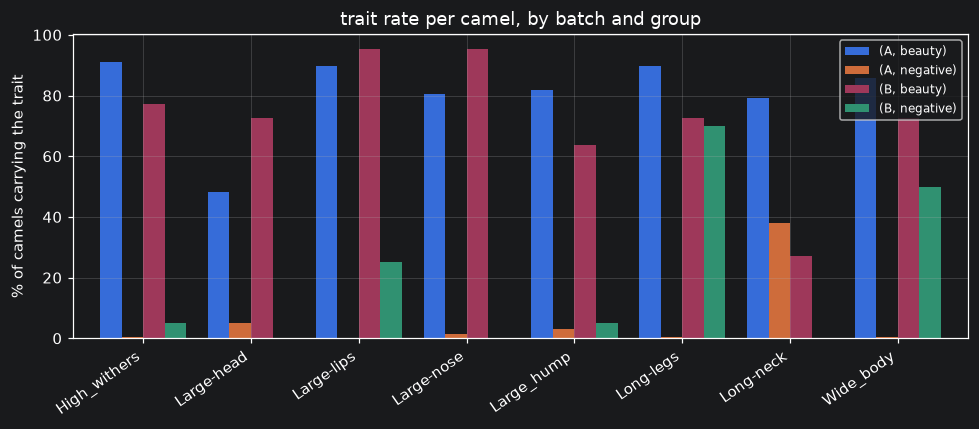

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
rate = counts.div(by_group.camels.reindex(counts.index), axis=0) * 100
rate.T.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("% of camels carrying the trait")
ax.set_xlabel("")
ax.set_title("trait rate per camel, by batch and group")
ax.legend(title="", fontsize=8)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

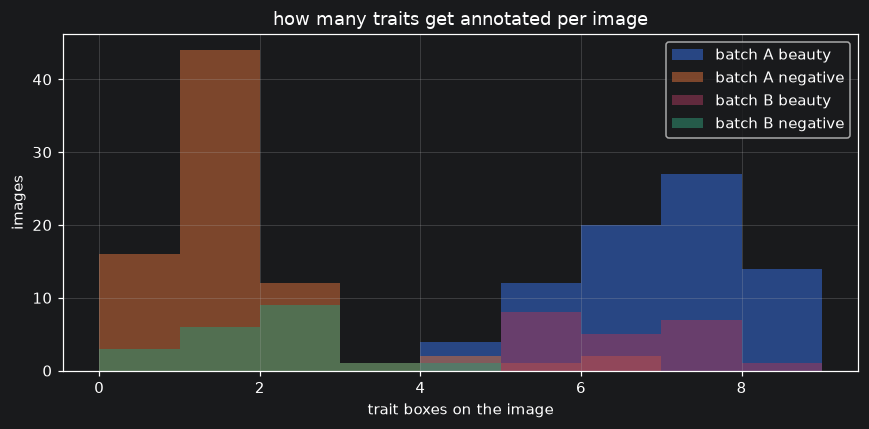

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
for key, g in imgs.groupby(["batch", "group"]):
    ax.hist(g.traits, bins=range(0, 10), alpha=0.55, label=f"batch {key[0]} {key[1]}")
ax.set_xlabel("trait boxes on the image")
ax.set_ylabel("images")
ax.set_title("how many traits get annotated per image")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 camels per image

if one group is mostly crowded scenes and the rest are portraits, the model can
learn "many camels = ugly" instead of learning beauty.

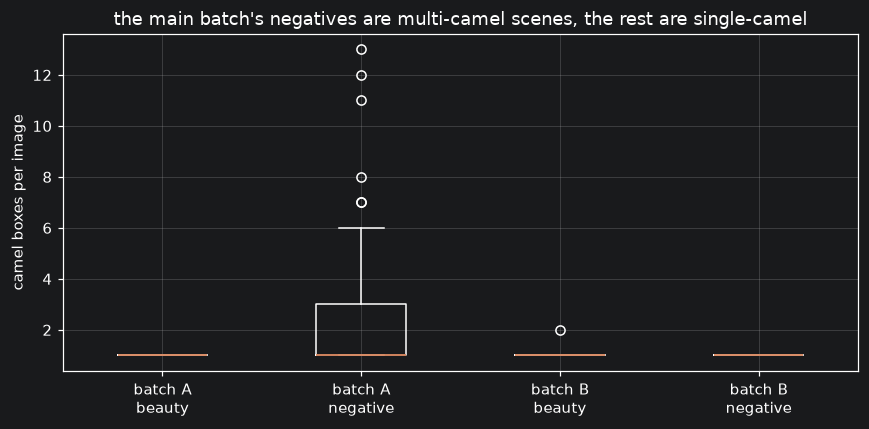

mean  min  50%   max
batch group                         
A     beauty    1.00  1.0  1.0   1.0
      negative  2.50  1.0  1.0  13.0
B     beauty    1.05  1.0  1.0   2.0
      negative  1.00  1.0  1.0   1.0

In [18]:
pairs = [("A", "beauty"), ("A", "negative"), ("B", "beauty"), ("B", "negative")]
data = [imgs[(imgs.batch == b) & (imgs.group == g)].camels for b, g in pairs]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data, tick_labels=[f"batch {b}\n{g}" for b, g in pairs])
ax.set_ylabel("camel boxes per image")
ax.set_title("the main batch's negatives are multi-camel scenes, the rest are single-camel")
plt.tight_layout()
plt.show()

imgs.groupby(["batch", "group"]).camels.describe()[["mean", "min", "50%", "max"]].round(2)

## 7. box size

small objects are what detectors miss. the annotation guide calls the lips the
box that decides the placing most often.

`envelope` below only *measures* a shape, it does not change the stored data —
polygons stay polygons on disk.

In [19]:
def envelope(geo):
    if len(geo) == 4:
        return geo[2], geo[3]
    xs, ys = geo[0::2], geo[1::2]
    return max(xs) - min(xs), max(ys) - min(ys)


boxed = pd.DataFrame(raw)
boxed[["w", "h"]] = boxed.geo.apply(lambda g: pd.Series(envelope(g)))
boxed["area"] = boxed.w * boxed.h

area = boxed.groupby("cls").area.describe()[["count", "mean", "50%", "max"]].round(4)
area = area.sort_values("50%")
print("relative box area, smallest class first")
area

relative box area, smallest class first


,count,mean,50%,max
cls,,,,
Large-lips,95.0,0.0028,0.0027,0.0119
Large-nose,86.0,0.0038,0.0033,0.0206
Wide_body,93.0,0.0094,0.0077,0.0440
High_withers,89.0,0.0220,0.0190,0.0691
Large-head,63.0,0.0264,0.0278,0.0699
Large_hump,84.0,0.0353,0.0317,0.0830
Long-neck,141.0,0.0435,0.0422,0.1875
Long-legs,100.0,0.0576,0.0518,0.1623
Camel,314.0,0.3491,0.3260,0.9725


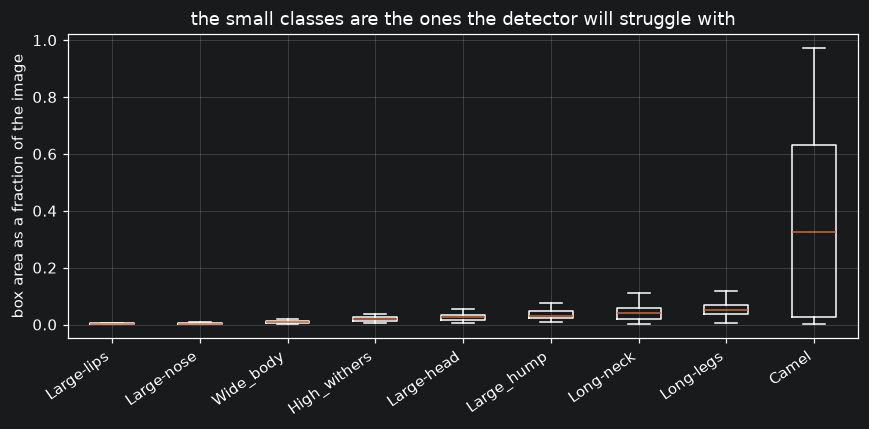

In [20]:
ordered = area.index.tolist()

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([boxed[boxed.cls == c].area for c in ordered], tick_labels=ordered, showfliers=False)
ax.set_ylabel("box area as a fraction of the image")
ax.set_title("the small classes are the ones the detector will struggle with")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 8. duplicates

a duplicate that lands in both train and test inflates the score. a duplicate
across the pretty and ugly sets is worse — the same photo labelled both ways.

In [21]:
paths = []
for f in folders:
    d = os.path.join(root, f, "train", "images")
    for name in sorted(os.listdir(d)):
        paths.append((short[f], stem(name), os.path.join(d, name)))

hashes = [(s, st, imagehash.phash(Image.open(p).convert("RGB"))) for s, st, p in paths]
print(f"hashed {len(hashes)} images")

found = []
for i in range(len(hashes)):
    for j in range(i + 1, len(hashes)):
        dist = hashes[i][2] - hashes[j][2]
        if dist <= 8:
            found.append({
                "distance": dist,
                "set_a": hashes[i][0], "image_a": hashes[i][1],
                "set_b": hashes[j][0], "image_b": hashes[j][1],
            })

dupes = pd.DataFrame(found).sort_values("distance").reset_index(drop=True)
print(f"pairs within hamming distance 8: {len(dupes)}")
print("0 = identical, <=8 = near duplicate such as a burst shot, crop or re-encode")
dupes

hashed 196 images
pairs within hamming distance 8: 18
0 = identical, <=8 = near duplicate such as a burst shot, crop or re-encode


,distance,set_a,image_a,set_b,image_b
0,0,small pretty,beautiful_02_png,small ugly,beautiful_02_png
1,0,small ugly,beautiful_18_png,small ugly,beautiful_20_png
2,2,main,BEAUTY_062_jpeg,main,BEAUTY_076_jpeg
3,4,main,BEAUTY_035_jpeg,main,BEAUTY_052_jpeg
4,4,small ugly,beautiful_14_png,small ugly,beautiful_20_png
5,4,small ugly,beautiful_14_png,small ugly,beautiful_18_png
6,6,small pretty,WhatsApp Image 2026-09-04 at 4-17-26 PM (3)_jpeg,small pretty,WhatsApp Image 2026-09-04 at 4-17-28 PM (3)_jpeg
7,6,small ugly,beautiful_01_png,small ugly,beautiful_07_png
8,6,small ugly,beautiful_02_png,small ugly,beautiful_12_png
9,6,small pretty,beautiful_06_png,small ugly,beautiful_12_png


### 8.1 the ones that matter

In [22]:
cross = dupes[dupes.set_a != dupes.set_b]
print(f"cross-set pairs      {len(cross)}   would be counted twice after merging")
print(f"within-set pairs     {len(dupes) - len(cross)}   must not straddle a train/test split")
print()

contradictions = cross[
    ((cross.set_a == "small pretty") & (cross.set_b == "small ugly"))
    | ((cross.set_a == "small ugly") & (cross.set_b == "small pretty"))
]
print(f"pretty/ugly contradictions: {len(contradictions)}")
print("the same photo labelled both ways - a human has to pick which is right")
contradictions

cross-set pairs      6   would be counted twice after merging
within-set pairs     12   must not straddle a train/test split

pretty/ugly contradictions: 4
the same photo labelled both ways - a human has to pick which is right


,distance,set_a,image_a,set_b,image_b
0,0,small pretty,beautiful_02_png,small ugly,beautiful_02_png
9,6,small pretty,beautiful_06_png,small ugly,beautiful_12_png
10,6,small pretty,beautiful_02_png,small ugly,beautiful_12_png
13,8,small pretty,beautiful_02_png,small ugly,beautiful_14_png


## 9. merge

renames every image to `<group>_<batch><nnn>` so the origin stays visible, and
writes a manifest mapping each new name back to the file it came from.

geometry is copied through byte for byte — polygons stay polygons, because the
model choice is still open and a segmentation model would need them.

In [23]:
def build_merged(root, out):
    rows = read_all()
    polygon_stems = {(r["folder"], r["stem"]) for r in rows if r["polygon"]}

    by_img = {}
    for r in rows:
        by_img.setdefault((r["folder"], r["stem"]), []).append(r)

    # deterministic order so a rebuild produces identical names
    keys = sorted(by_img, key=lambda k: (by_img[k][0]["group"], by_img[k][0]["batch"], k[1]))

    # wipe first, otherwise files from an earlier run survive and pad the dataset
    shutil.rmtree(out, ignore_errors=True)

    img_dir, lab_dir = os.path.join(out, "images"), os.path.join(out, "labels")
    os.makedirs(img_dir)
    os.makedirs(lab_dir)

    counter, manifest = {}, []
    for key in keys:
        anns = by_img[key]
        group, batch = anns[0]["group"], anns[0]["batch"]
        bucket = f"{'BEAUTY' if group == 'beauty' else 'NEGATIVE'}_{batch}"
        counter[bucket] = counter.get(bucket, 0) + 1
        new_stem = f"{bucket}{counter[bucket]:03d}"

        folder, old_stem = key
        src_img = os.path.join(root, folder, "train", "images")
        match = [f for f in os.listdir(src_img) if stem(f) == old_stem][0]
        ext = os.path.splitext(match)[1]
        shutil.copy2(os.path.join(src_img, match), os.path.join(img_dir, new_stem + ext))

        lines = [f"{canon.index(a['cls'])} " + " ".join(f"{v:.6f}" for v in a["geo"]) for a in anns]
        with open(os.path.join(lab_dir, new_stem + ".txt"), "w", encoding="utf-8") as fh:
            fh.write("\n".join(lines) + "\n")

        manifest.append({
            "new_name": new_stem + ext,
            "bucket": bucket,
            "group": group,
            "batch": batch,
            "source_folder": folder,
            "original_stem": old_stem,
            "annotations": len(anns),
            "camel_boxes": sum(1 for a in anns if a["is_camel"]),
            "trait_boxes": sum(1 for a in anns if not a["is_camel"]),
            "had_polygons": key in polygon_stems,
        })

    with open(os.path.join(out, "manifest.csv"), "w", newline="", encoding="utf-8") as fh:
        w = csv.DictWriter(fh, fieldnames=list(manifest[0].keys()))
        w.writeheader()
        w.writerows(manifest)

    with open(os.path.join(out, "data.yaml"), "w", encoding="utf-8") as fh:
        fh.write("path: .\ntrain: images\nval: images\n\n")
        fh.write(f"nc: {len(canon)}\n")
        fh.write("names: [" + ", ".join(f"'{c}'" for c in canon) + "]\n\n")
        fh.write("# not split yet - train and val both point at images/\n")

    return manifest, rows

In [24]:
manifest, merged_rows = build_merged(root, out)
mf = pd.DataFrame(manifest)

print(f"images {len(mf)}   annotations {len(merged_rows)}")
mf.head(10)

images 196   annotations 1065


,new_name,bucket,group,batch,source_folder,original_stem,annotations,camel_boxes,trait_boxes,had_polygons
0,BEAUTY_A001.jpg,BEAUTY_A,beauty,A,Camel-Beauty-Classfier-Pretty.yolov8 (1),BEAUTY_001_jpg,7,1,6,False
1,BEAUTY_A002.jpeg,BEAUTY_A,beauty,A,Camel-Beauty-Classfier-Pretty.yolov8 (1),BEAUTY_002_jpeg,7,1,6,False
2,BEAUTY_A003.jpg,BEAUTY_A,beauty,A,Camel-Beauty-Classfier-Pretty.yolov8 (1),BEAUTY_003_jpg,8,1,7,False
3,BEAUTY_A004.jpg,BEAUTY_A,beauty,A,Camel-Beauty-Classfier-Pretty.yolov8 (1),BEAUTY_004_jpg,7,1,6,False
4,BEAUTY_A005.jpg,BEAUTY_A,beauty,A,Camel-Beauty-Classfier-Pretty.yolov8 (1),BEAUTY_005_jpg,9,1,8,False
5,BEAUTY_A006.jpg,BEAUTY_A,beauty,A,Camel-Beauty-Classfier-Pretty.yolov8 (1),BEAUTY_006_jpg,8,1,7,False
6,BEAUTY_A007.jpg,BEAUTY_A,beauty,A,Camel-Beauty-Classfier-Pretty.yolov8 (1),BEAUTY_007_jpg,6,1,5,False
7,BEAUTY_A008.jpg,BEAUTY_A,beauty,A,Camel-Beauty-Classfier-Pretty.yolov8 (1),BEAUTY_008_jpg,8,1,7,False
8,BEAUTY_A009.jpg,BEAUTY_A,beauty,A,Camel-Beauty-Classfier-Pretty.yolov8 (1),BEAUTY_009_jpg,7,1,6,False
9,BEAUTY_A010.jpg,BEAUTY_A,beauty,A,Camel-Beauty-Classfier-Pretty.yolov8 (1),BEAUTY_010_jpg,7,1,6,False


## 10. verification

the merge is only trustworthy if nothing changed except the names and the
polygon→box conversion.

In [25]:
check = pd.DataFrame({"before_merge": summarise(raw), "after_merge": summarise(merged_rows)})
check["match"] = check.before_merge == check.after_merge
check

,before_merge,after_merge,match
images,196.00,196.00,True
annotations,1065.00,1065.00,True
camel_boxes,314.00,314.00,True
trait_boxes,751.00,751.00,True
from_polygon,307.00,307.00,True
camels_per_image,1.60,1.60,True
traits_per_camel,2.39,2.39,True


In [26]:
per_class = pd.DataFrame({
    "before": df.cls.value_counts(),
    "after": pd.DataFrame(merged_rows).cls.value_counts(),
}).reindex(canon).fillna(0).astype(int)
per_class["match"] = per_class.before == per_class.after
per_class

,before,after,match
cls,,,
Camel,314,314,True
High_withers,89,89,True
Large-head,63,63,True
Large-lips,95,95,True
Large-nose,86,86,True
Large_hump,84,84,True
Long-legs,100,100,True
Long-neck,141,141,True
Wide_body,93,93,True


In [27]:
field_counts = collections.Counter()
written_classes = collections.Counter()
for f in sorted(os.listdir(os.path.join(out, "labels"))):
    with open(os.path.join(out, "labels", f), encoding="utf-8") as fh:
        for line in fh:
            if line.strip():
                parts = line.split()
                field_counts[len(parts)] += 1
                written_classes[canon[int(parts[0])]] += 1

src_fields = collections.Counter(len(r["geo"]) + 1 for r in raw)

print(f"label lines on disk        {sum(field_counts.values())}")
print(f"class totals match source  {written_classes == collections.Counter(df.cls)}")
print(f"geometry preserved exactly {field_counts == src_fields}")
print()
print(f"  box lines (5 fields)     {field_counts[5]}")
print(f"  polygon lines            {sum(v for k, v in field_counts.items() if k != 5)}")
print()
print(mf.bucket.value_counts().sort_index().to_string())
print()
print(f"images holding at least one polygon: {mf.had_polygons.sum()}")
print(f"manifest: {out}/manifest.csv")

label lines on disk        1065
class totals match source  True
geometry preserved exactly True

  box lines (5 fields)     758
  polygon lines            307

bucket
BEAUTY_A      77
BEAUTY_B      21
NEGATIVE_A    78
NEGATIVE_B    20

images holding at least one polygon: 94
manifest: dataset/camel-merged-v1/manifest.csv


## 11. the merged dataset

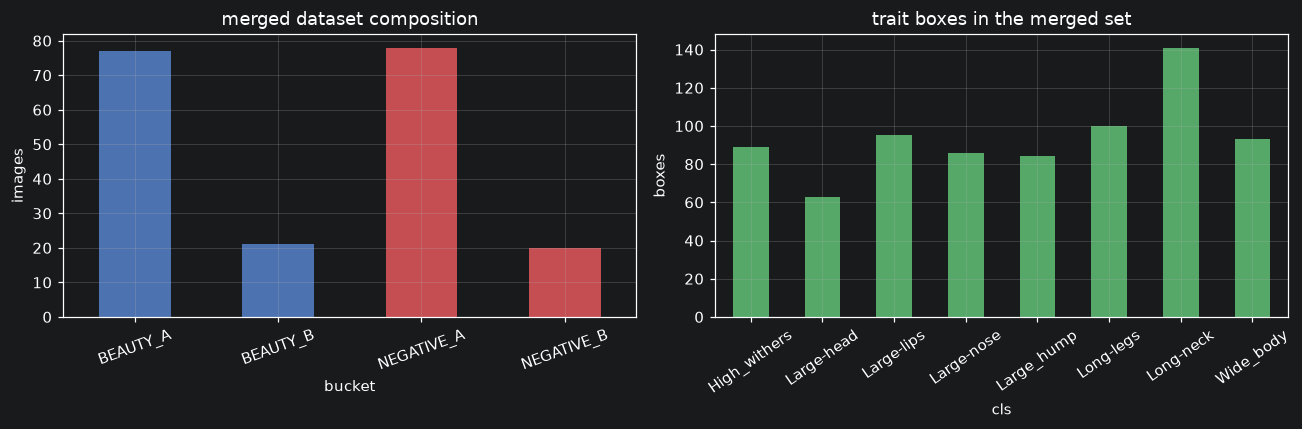

In [28]:
merged = pd.DataFrame(merged_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mf.bucket.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#4c72b0", "#4c72b0", "#c44e52", "#c44e52"])
axes[0].set_title("merged dataset composition")
axes[0].set_ylabel("images")
axes[0].tick_params(axis="x", rotation=20)

merged[~merged.is_camel].cls.value_counts().reindex(traits).plot(
    kind="bar", ax=axes[1], color="#55a868")
axes[1].set_title("trait boxes in the merged set")
axes[1].set_ylabel("boxes")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

## 12. samples

annotated samples, for the data deliverable. solid outline = a stored box,
dashed = the envelope of a stored polygon, drawn only so it is visible here.

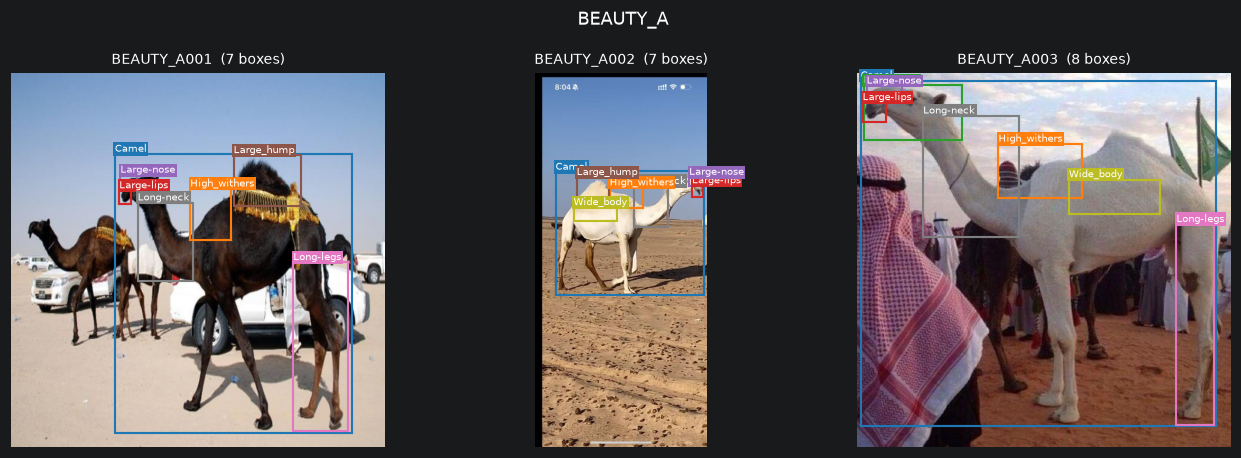

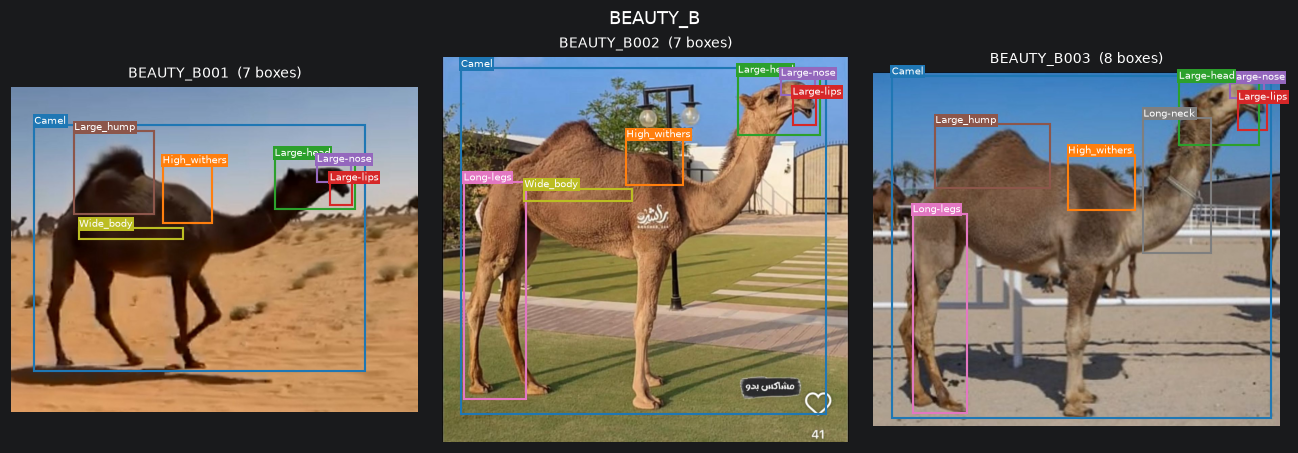

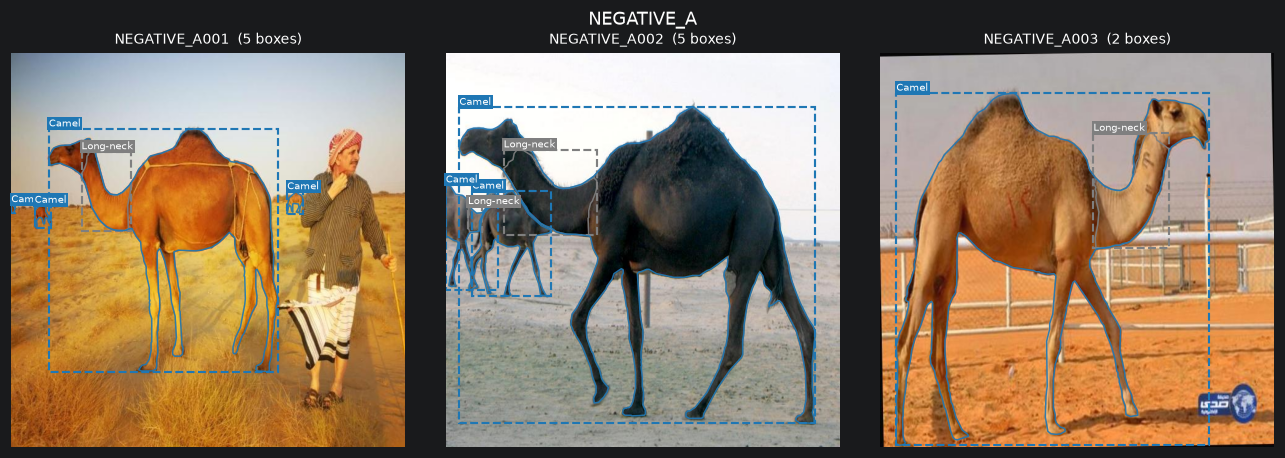

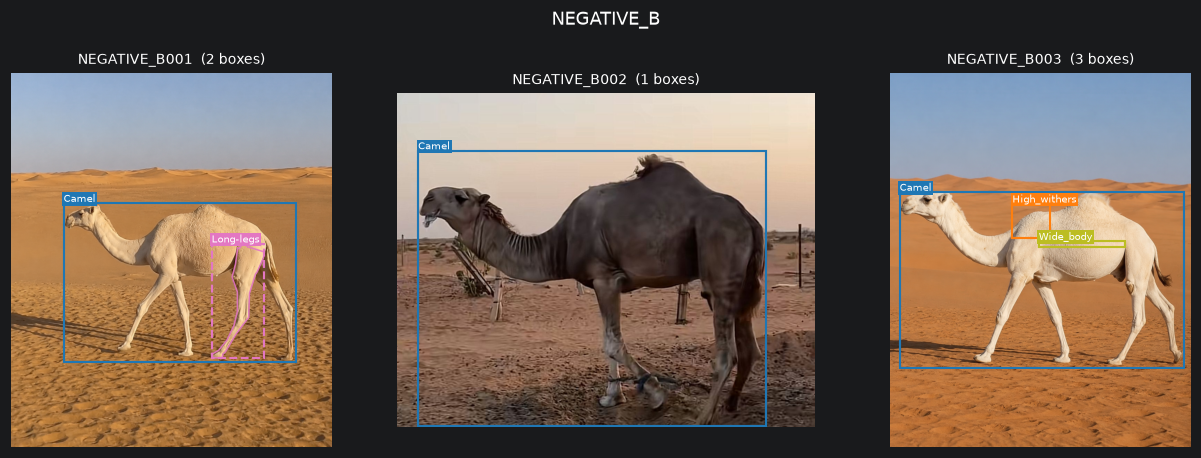

In [29]:
def show_samples(names, title):
    fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 4.2))
    if len(names) == 1:
        axes = [axes]
    colors = plt.cm.tab10.colors
    for ax, name in zip(axes, names):
        base = os.path.splitext(name)[0]
        img = Image.open(os.path.join(out, "images", name)).convert("RGB")
        w, h = img.size
        ax.imshow(img)
        with open(os.path.join(out, "labels", base + ".txt"), encoding="utf-8") as fh:
            lines = [l.split() for l in fh if l.strip()]
        for p in lines:
            cid = int(p[0])
            geo = [float(v) for v in p[1:]]
            if len(geo) == 4:
                xc, yc, bw, bh = geo
                x, y = (xc - bw / 2) * w, (yc - bh / 2) * h
                bw, bh = bw * w, bh * h
            else:
                xs, ys = [v * w for v in geo[0::2]], [v * h for v in geo[1::2]]
                ax.plot(xs + xs[:1], ys + ys[:1], lw=1.0, color=colors[cid % 10], alpha=0.9)
                x, y = min(xs), min(ys)
                bw, bh = max(xs) - x, max(ys) - y
            ax.add_patch(plt.Rectangle((x, y), bw, bh, fill=False, lw=1.4,
                                       ls="--" if len(geo) > 4 else "-",
                                       edgecolor=colors[cid % 10]))
            ax.text(x, y - 4, canon[cid], fontsize=6.5, color="white",
                    bbox=dict(facecolor=colors[cid % 10], pad=1, edgecolor="none"))
        ax.set_title(f"{base}  ({len(lines)} boxes)", fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


for bucket in ["BEAUTY_A", "BEAUTY_B", "NEGATIVE_A", "NEGATIVE_B"]:
    picks = sorted(mf[mf.bucket == bucket].new_name)[:3]
    if picks:
        show_samples(picks, bucket)